This notebook evaluates the impact of AI on the workforce. After viewing my initial large correlation matrix, I noticed strong correlation between employees displaced, created, and reskilled. This notebook investigates this further. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [2]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

df_country = pd.read_csv("../Data/country_ai_index.csv")

In [3]:
# I want to merge country to company for the correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [4]:
workforce = df_company[
    [
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees"
    ]
]

workforce.head()

,jobs_created,jobs_displaced,reskilled_employees
0,1,1,3
1,2,2,5
2,3,3,2
3,1,1,2
4,3,2,6


In [ ]:
# This correlation and associated heat map below show a callout of how workforce transformation has strong positive relationships
workforce_corr = workforce.corr()

workforce_corr

,jobs_created,jobs_displaced,reskilled_employees
jobs_created,1.000000,0.923838,0.923788
jobs_displaced,0.923838,1.000000,0.876548
reskilled_employees,0.923788,0.876548,1.000000


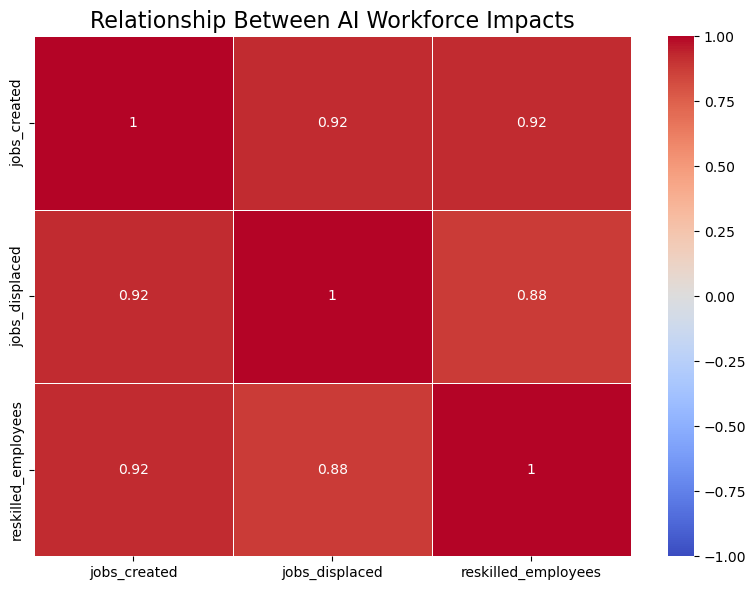

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    workforce_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=.5
)
plt.title(
    "Relationship Between AI Workforce Impacts",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [7]:
# This correlation checked how the number of employees impacted workforce transformation
size_check = df_company[
    [
        "num_employees",
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees"
    ]
]

size_check.corr()

,num_employees,jobs_created,jobs_displaced,reskilled_employees
num_employees,1.000000,0.932788,0.895889,0.901693
jobs_created,0.932788,1.000000,0.923838,0.923788
jobs_displaced,0.895889,0.923838,1.000000,0.876548
reskilled_employees,0.901693,0.923788,0.876548,1.000000


In [ ]:
# This creates a variable to group by company size (enterprise, small, SME) and evaluate the av of the three 
#columns included
workforce_size = (
    df_company.groupby("company_size")
    [
        [
            "jobs_created",
            "jobs_displaced",
            "reskilled_employees"
        ]
    ]
    .mean()
)

workforce_size

,jobs_created,jobs_displaced,reskilled_employees
company_size,,,
Enterprise,546.694750,514.283551,844.486077
SME,22.776911,22.433463,34.324033
Startup,2.268960,2.259787,3.277869


In [9]:
# Normalize this data by creating a percent
df_company["created_percent"] = (
    df_company["jobs_created"]
    / df_company["num_employees"]
    * 100
)

df_company["displaced_percent"] = (
    df_company["jobs_displaced"]
    / df_company["num_employees"]
    * 100
)

df_company["reskilled_percent"] = (
    df_company["reskilled_employees"]
    / df_company["num_employees"]
    * 100
)

In [ ]:
workforce_percent = (
    df_company.groupby("company_size")
    [
        [
            "created_percent",
            "displaced_percent",
            "reskilled_percent"
        ]
    ]
    .mean()
)

workforce_percent

,created_percent,displaced_percent,reskilled_percent
company_size,,,
Enterprise,5.170532,4.862986,7.983460
SME,4.182163,4.116980,6.314984
Startup,4.145696,4.121613,5.992857


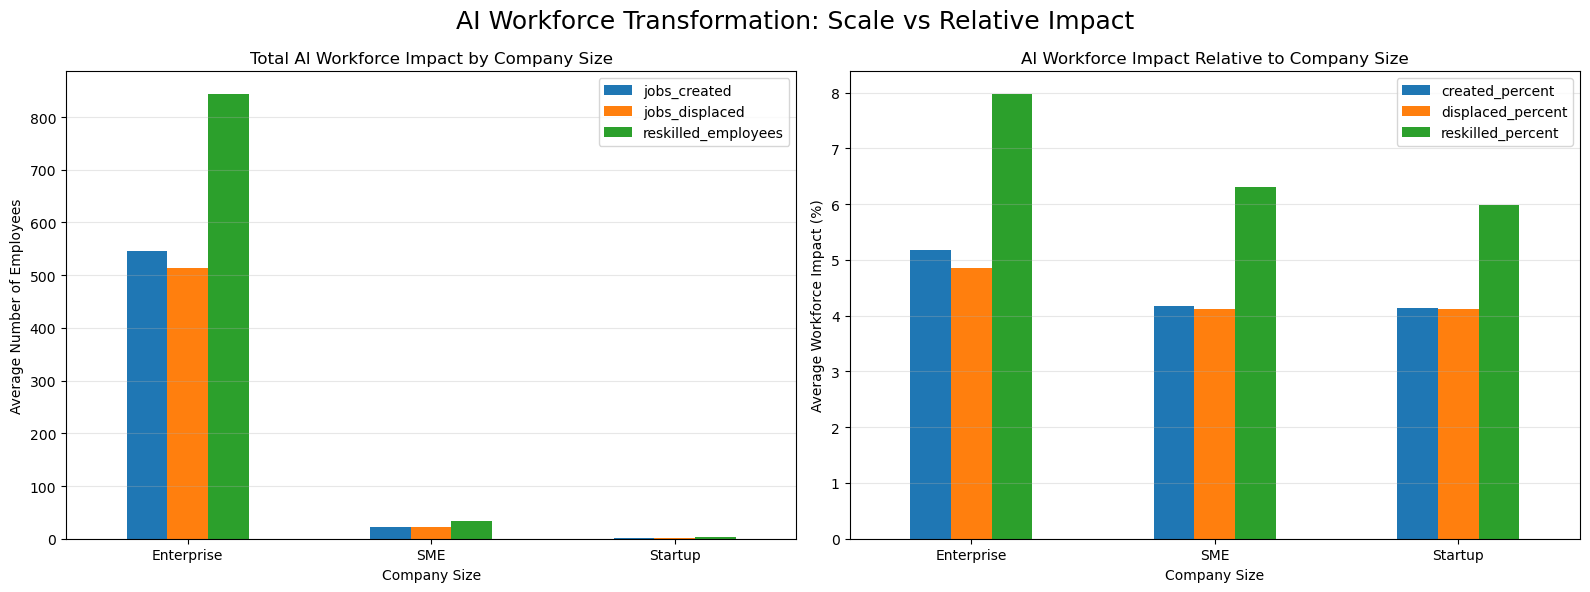

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(16,6))

# Raw employee counts
workforce_size.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Total AI Workforce Impact by Company Size")

axes[0].set_xlabel("Company Size")

axes[0].set_ylabel("Average Number of Employees")

axes[0].tick_params(axis="x",rotation=0)

axes[0].grid(axis="y",alpha=0.3)

# Normalized percentages
workforce_percent.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("AI Workforce Impact Relative to Company Size")

axes[1].set_xlabel("Company Size")

axes[1].set_ylabel("Average Workforce Impact (%)")

axes[1].tick_params(axis="x",rotation=0)

axes[1].grid(axis="y", alpha=0.3)
plt.suptitle("AI Workforce Transformation: Scale vs Relative Impact",fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# renaming columns for cleaner chart legen below
workforce_size = workforce_size.rename(
    columns={
        "jobs_created": "Jobs Created",
        "jobs_displaced": "Jobs Displaced",
        "reskilled_employees": "Employees Reskilled"
    }
)

workforce_percent = workforce_percent.rename(
    columns={
        "created_percent": "Jobs Created",
        "displaced_percent": "Jobs Displaced",
        "reskilled_percent": "Employees Reskilled"
    }
)

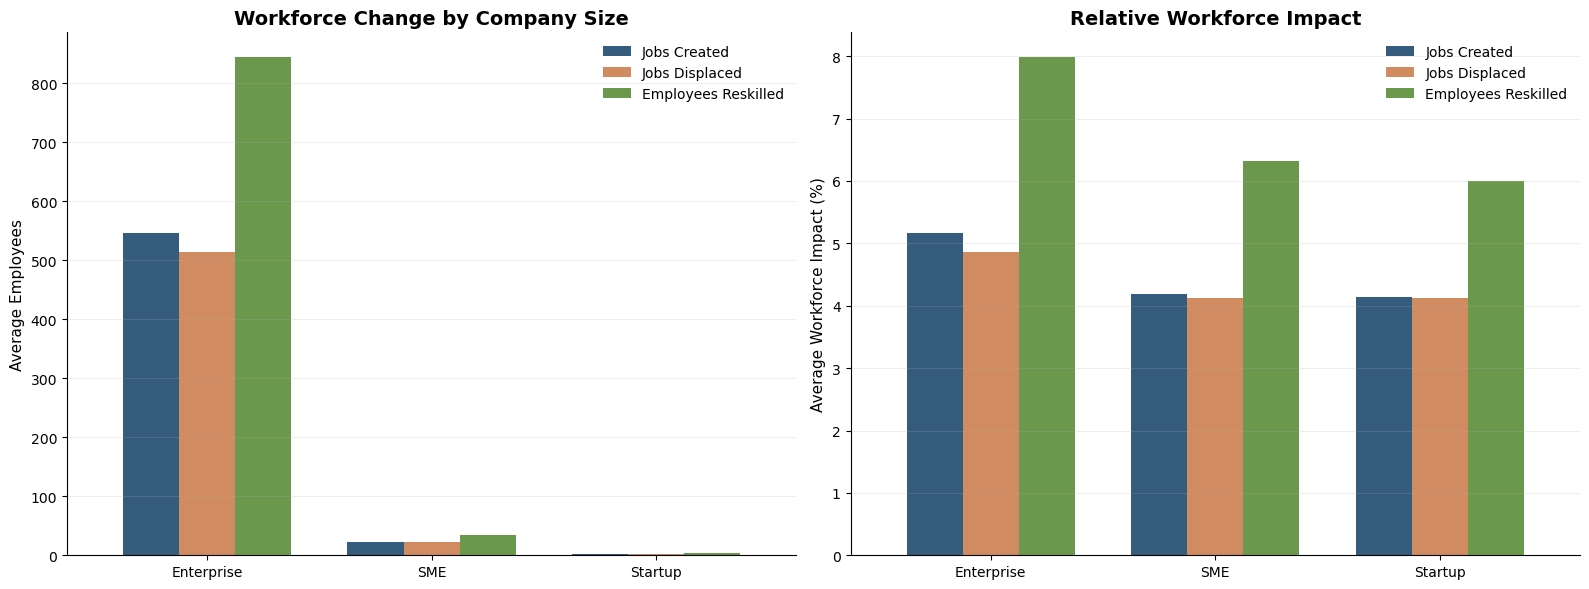

: 

In [ ]:
# clean version of above chart

# bar colors
colors = [
    "#355C7D",
    "#D08C60", 
    "#6A994E"  
]

fig, axes = plt.subplots(1,2,figsize=(16, 6))

# Raw employee counts LEFT

workforce_size.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    width=0.75
)

axes[0].set_title(
    "Workforce Change by Company Size",
    fontsize=14,
    weight="bold"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Average Employees",fontsize=11)

axes[0].tick_params(
    axis="x",
    rotation=0
)

axes[0].grid(
    axis="y",
    alpha=0.2
)
# invisible spines
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)


# Percent impact RIGHT

workforce_percent.plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    width=0.75
)

axes[1].set_title(
    "Relative Workforce Impact",
    fontsize=14,
    weight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel(
    "Average Workforce Impact (%)",
    fontsize=11
)

axes[1].tick_params(
    axis="x",
    rotation=0
)

axes[1].grid(
    axis="y",
    alpha=0.2
)
# invisible spines
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


# Cleaner legends
for ax in axes:
    ax.legend(
        frameon=False,
        fontsize=10
    )

plt.tight_layout()

plt.show()

The evaluation below displays the mean changes between creation and displacement for each company size. All slightly positive. 

In [16]:
# setting column that calculates the percent change
df_company["net_job_change_percent"] = (
    (df_company["jobs_created"] - df_company["jobs_displaced"])
    / df_company["num_employees"]
    * 100
)

In [13]:
# getting the average percent of change for each company size
df_company.groupby("company_size")[
    "net_job_change_percent"
].mean()

company_size
Enterprise    0.307546
SME           0.065184
Startup       0.024082
Name: net_job_change_percent, dtype: float64

dataset is not showing a large net change in jobs. all slightly positive.